In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("heart.csv")

# View first few rows
print(df.head())

# Check data types and missing values
print(df.info())
print(df.isnull().sum())

# Class distribution
print(df['HeartDisease'].value_counts())


   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy dataframe so original stays safe
data = df.copy()

# List categorical columns to encode
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Initialize LabelEncoder
le = LabelEncoder()

# Encode each categorical column
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Separate features and target
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to verify
print("Training feature set shape:", X_train.shape)
print("Test feature set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


Training feature set shape: (734, 11)
Test feature set shape: (184, 11)
Training labels shape: (734,)
Test labels shape: (184,)


# **Logistic Regression**

Accuracy: 0.842391304347826

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82        77
           1       0.91      0.81      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.84      0.84       184



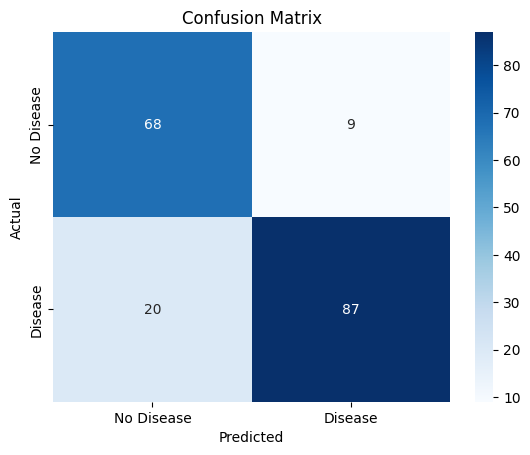

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# **Feature Scaling and SVM model**

SVM Accuracy: 0.8641304347826086

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



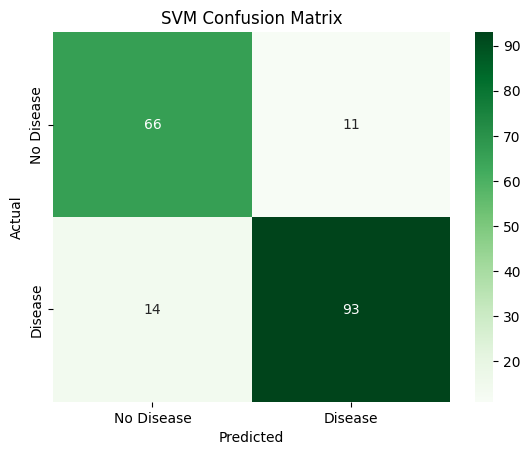

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training features and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize SVM model with default parameters
svm_model = SVC(random_state=42)

# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()


# **Hyperparameter tuning for SVM model**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initialize SVM
svm = SVC(random_state=42)

# Initialize GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit GridSearch on scaled training data
grid_search.fit(X_train_scaled, y_train)

# Best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate best model on test set
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("\nTest set accuracy:", accuracy_score(y_test, y_pred_best))
print("\nTest set classification report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.866470971950424

Test set accuracy: 0.8641304347826086

Test set classification report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



# **Random Forest Classifier**

Random Forest Accuracy: 0.8804347826086957

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



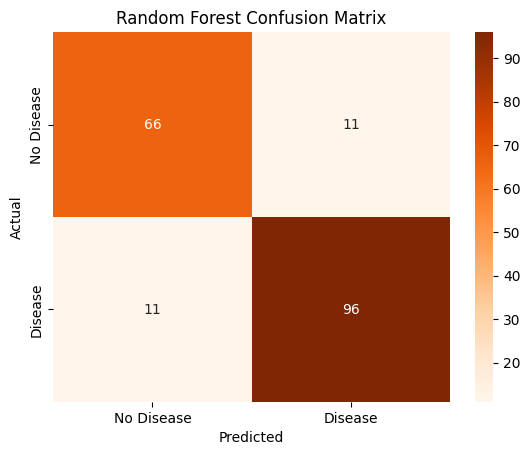

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with default parameters
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion matrix heatmap
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


# **Hyperparameter tuning for Random Forest**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearch with 5-fold CV
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit on training data
grid_search_rf.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validation accuracy:", grid_search_rf.best_score_)

# Evaluate best model on test data
best_rf = grid_search_rf.best_estimator_
y_pred_rf_best = best_rf.predict(X_test)

print("\nTest set accuracy:", accuracy_score(y_test, y_pred_rf_best))
print("\nTest set classification report:\n", classification_report(y_test, y_pred_rf_best))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation accuracy: 0.8746528748485695

Test set accuracy: 0.8967391304347826

Test set classification report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88        77
           1       0.92      0.90      0.91       107

    accuracy                           0.90       184
   macro avg       0.89      0.90      0.89       184
weighted avg       0.90      0.90      0.90       184



# **ROC curve for RandomForest**


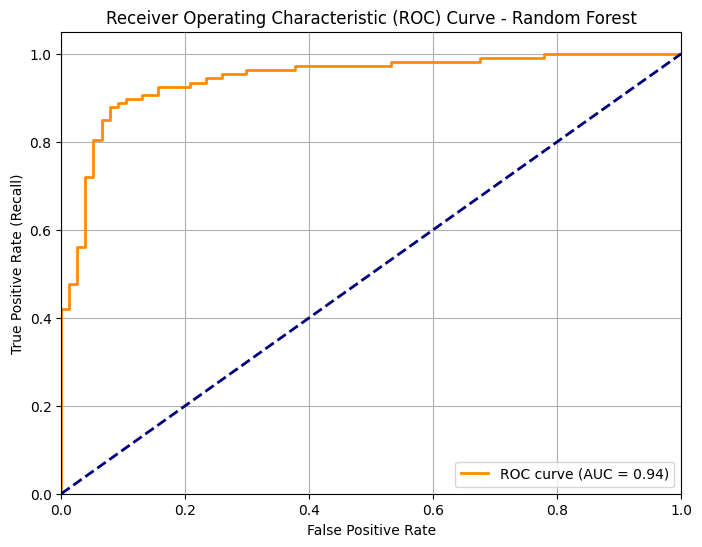

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
!pip install lightgbm


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# Prepare dataset for LightGBM
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Set parameters
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42
}

# Train LightGBM model
lgb_model = lgb.train(params, lgb_train, num_boost_round=100)

# Predict on test set (returns probabilities)
y_pred_lgb_prob = lgb_model.predict(X_test)

# Convert probabilities to binary predictions
y_pred_lgb = (y_pred_lgb_prob >= 0.5).astype(int)

# Evaluate
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("\nLightGBM Classification Report:\n", classification_report(y_test, y_pred_lgb))


LightGBM Accuracy: 0.8369565217391305

LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.81        77
           1       0.89      0.82      0.85       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# Initialize LGBMClassifier
lgbm = LGBMClassifier(random_state=42)

# Define parameter grid for tuning
param_grid = {
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.1, 0.05, 0.01],
    'n_estimators': [50, 100, 200],
    'min_child_samples': [20, 30, 40]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit on training data
grid_search.fit(X_train, y_train)

# Best params and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate best model on test set
best_lgbm = grid_search.best_estimator_
y_pred_best_lgbm = best_lgbm.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score
print("\nTest set accuracy:", accuracy_score(y_test, y_pred_best_lgbm))
print("\nTest set classification report:\n", classification_report(y_test, y_pred_best_lgbm))


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 40, 'n_estimators': 100, 'num_leaves': 31}
Best cross-validation accuracy: 0.8760134190662565

Test set accuracy: 0.8804347826086957

Test set classification report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86        77
           1       0.90      0.89      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



# **ROC Curve for LightGBM**

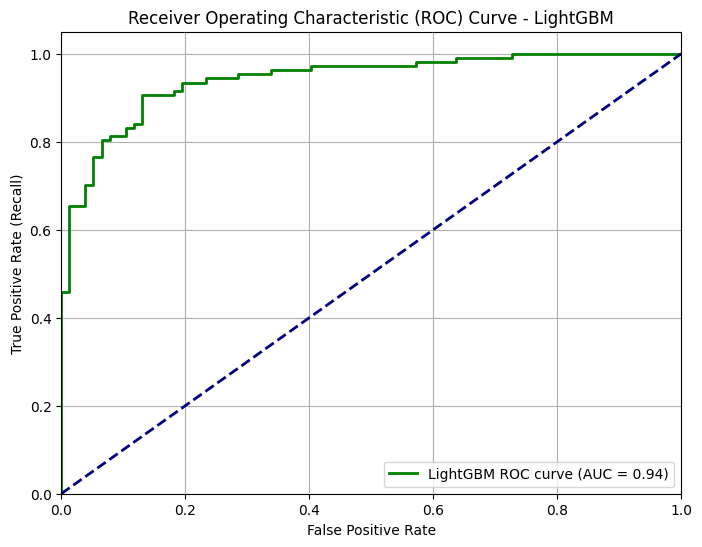

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_probs_lgb = best_lgbm.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_probs_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr_lgb, tpr_lgb, color='green', lw=2, label=f'LightGBM ROC curve (AUC = {roc_auc_lgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve - LightGBM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# **Comparing ROC Curve for RandomForest and LightGBM**

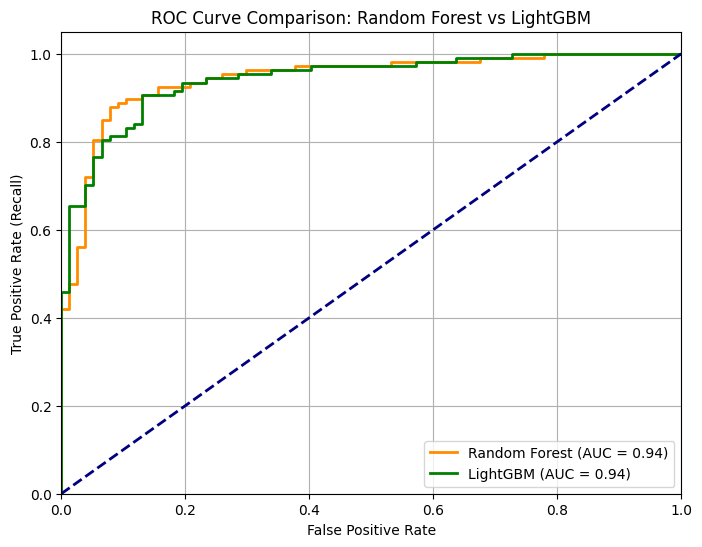

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for Random Forest and LightGBM
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]
y_probs_lgb = best_lgbm.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Compute ROC curve and AUC for LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_probs_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Plot ROC curves together
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_lgb, tpr_lgb, color='green', lw=2, label=f'LightGBM (AUC = {roc_auc_lgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: Random Forest vs LightGBM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
#SHAP EXPLAINABILITY - FIXED VERSION


# Install SHAP
!pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

# Initialize SHAP explainer with your best Random Forest model
# Using TreeExplainer because Random Forest is tree-based
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# FIX: For binary classification, shap_values is a list with 2 arrays
# Index 0 = SHAP values for class 0 (No Disease)
# Index 1 = SHAP values for class 1 (Disease)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]  # SHAP values for "Disease" class
    base_value = explainer.expected_value[1]  # Base value for positive class
else:
    shap_values_pos = shap_values
    base_value = explainer.expected_value

print("SHAP values computed successfully!")
print(f"Shape of SHAP values: {shap_values_pos.shape}")

SHAP values computed successfully!
Shape of SHAP values: (184, 11, 2)


<Figure size 1000x600 with 0 Axes>

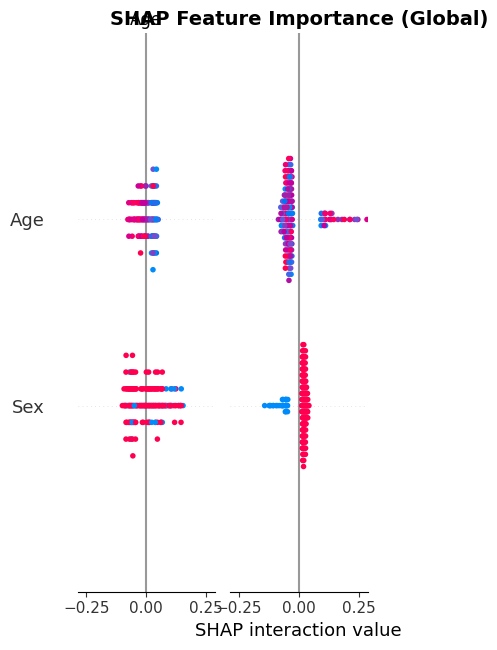

In [ ]:
# 1. SHAP Summary Plot (Global Feature Importance)
# Shows which features matter most across all predictions
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_pos, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

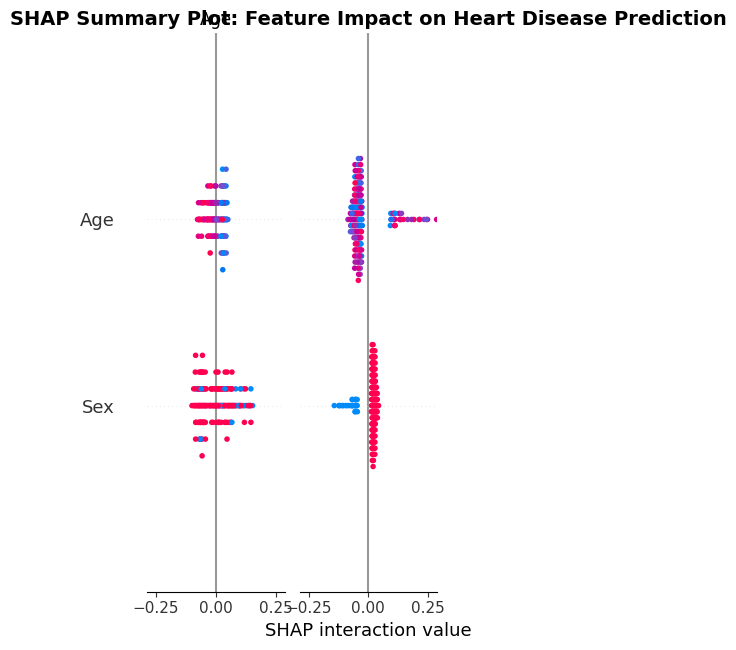

In [ ]:
# 2. SHAP Summary Plot (Beeswarm) - shows direction of impact
# Red = high feature value, Blue = low feature value
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_pos, X_test, show=False)
plt.title("SHAP Summary Plot: Feature Impact on Heart Disease Prediction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

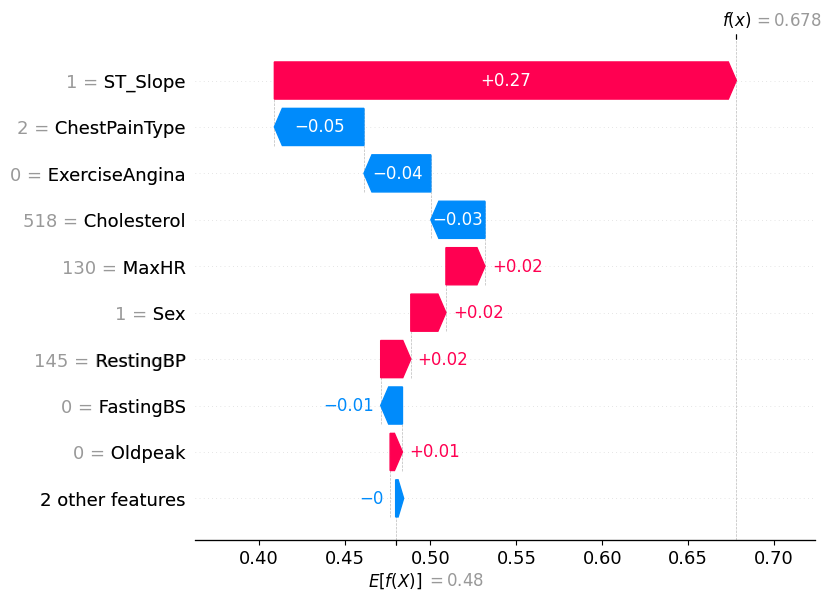

<Figure size 640x480 with 0 Axes>


Patient 1:
  Predicted: Disease
  Actual: Disease


In [ ]:
# 3. SHAP Waterfall Plot - CORRECT FIX

# Example 1: A patient predicted to have heart disease
disease_indices = np.where(y_pred_rf_best == 1)[0]
idx_disease = disease_indices[0]

# Create explainer without check_additivity parameter
explainer_new = shap.Explainer(best_rf, X_test)

# Call the explainer with check_additivity=False
shap_values_new = explainer_new(X_test, check_additivity=False)

# Plot waterfall for single patient (class 1 = Disease)
shap.plots.waterfall(shap_values_new[idx_disease, :, 1], max_display=10)
plt.tight_layout()
plt.show()

print(f"\nPatient {idx_disease}:")
print(f"  Predicted: {'Disease' if y_pred_rf_best[idx_disease] == 1 else 'No Disease'}")
print(f"  Actual: {'Disease' if y_test.iloc[idx_disease] == 1 else 'No Disease'}")

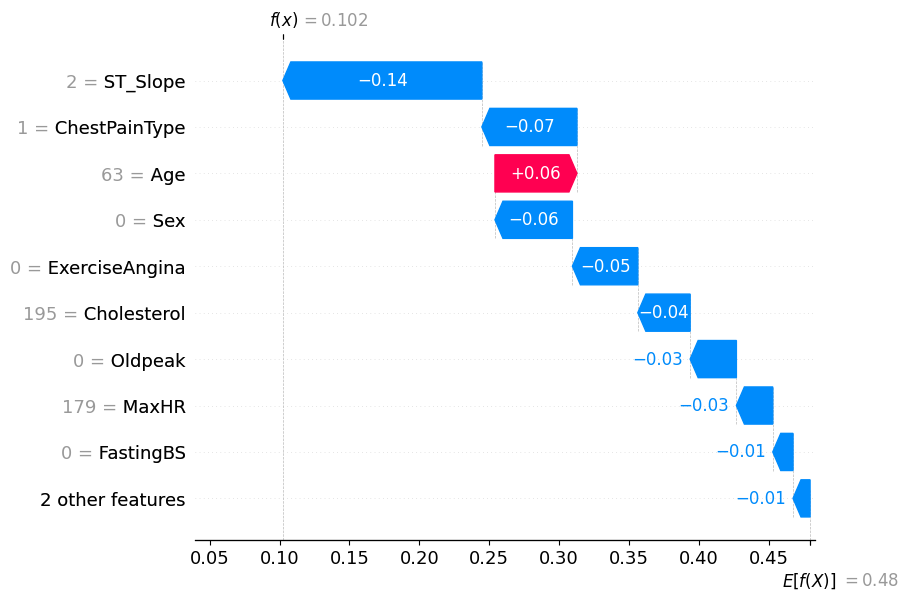

<Figure size 640x480 with 0 Axes>


Patient 0:
  Predicted: No Disease
  Actual: No Disease


In [ ]:
# Example 2: A patient predicted to NOT have heart disease
no_disease_indices = np.where(y_pred_rf_best == 0)[0]
idx_no_disease = no_disease_indices[0]

shap.plots.waterfall(shap_values_new[idx_no_disease, :, 1], max_display=10)
plt.tight_layout()
plt.show()

print(f"\nPatient {idx_no_disease}:")
print(f"  Predicted: {'Disease' if y_pred_rf_best[idx_no_disease] == 1 else 'No Disease'}")
print(f"  Actual: {'Disease' if y_test.iloc[idx_no_disease] == 1 else 'No Disease'}")

Force Plot - Patient with Disease Prediction:


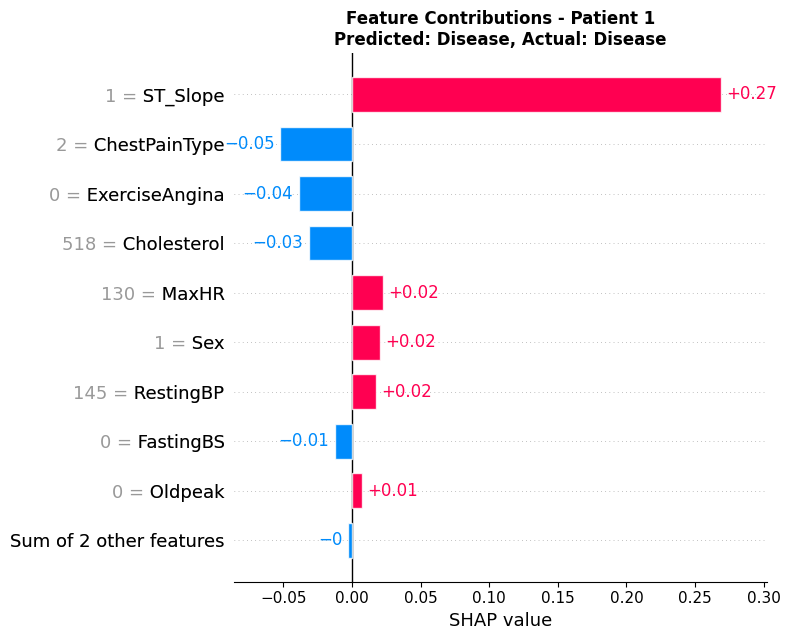

In [ ]:
# 4. SHAP Force Plot and Bar Plot for single predictions

# Initialize JavaScript for interactive plots
shap.initjs()

# Force plot using the new shap_values_new object
print("Force Plot - Patient with Disease Prediction:")
shap.plots.force(shap_values_new[idx_disease, :, 1])

# Also create a bar plot as alternative visualization
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_new[idx_disease, :, 1], max_display=10, show=False)
plt.title(f'Feature Contributions - Patient {idx_disease}\nPredicted: Disease, Actual: {"Disease" if y_test.iloc[idx_disease] else "No Disease"}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

shap_values_disease shape: (184, 11)
feature_importance shape: (11,)

Top 3 Most Important Features:
1. ST_Slope (mean |SHAP| = 0.179)
2. ExerciseAngina (mean |SHAP| = 0.082)
3. ChestPainType (mean |SHAP| = 0.080)


<Figure size 800x500 with 0 Axes>

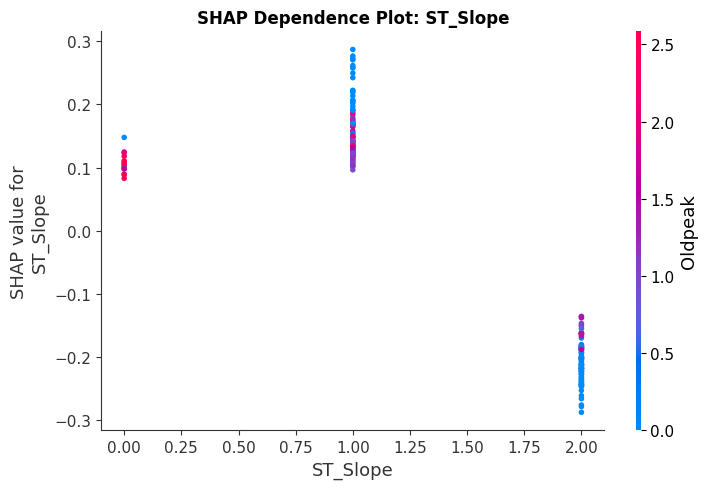

<Figure size 800x500 with 0 Axes>

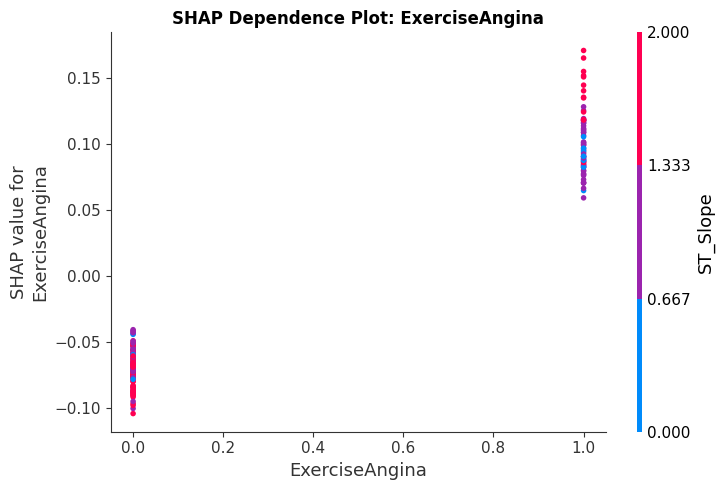

<Figure size 800x500 with 0 Axes>

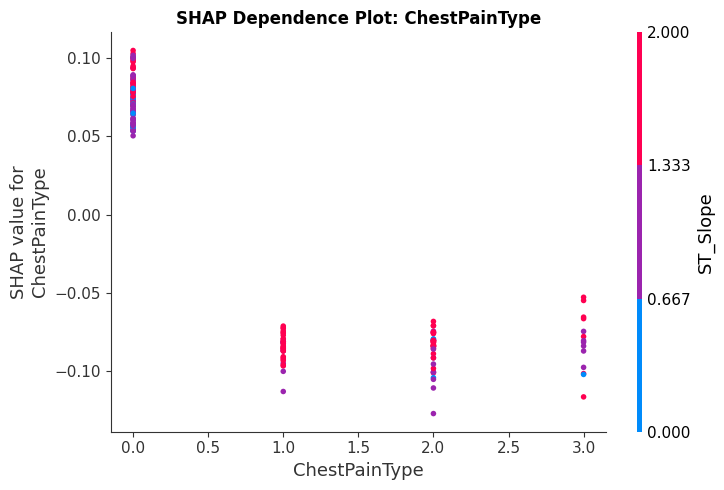

In [ ]:
# 5. SHAP Dependence Plots - COMPLETE FIX
# The issue: shap_values_pos is (184, 11, 2) - still has both classes!

# Extract only the positive class (Disease = class 1)
shap_values_disease = shap_values_pos[:, :, 1]  # Shape: (184, 11)

print(f"shap_values_disease shape: {shap_values_disease.shape}")

# Now calculate feature importance - should be 1D with 11 values
feature_importance = np.abs(shap_values_disease).mean(axis=0)
print(f"feature_importance shape: {feature_importance.shape}")

top_features_idx = np.argsort(feature_importance)[-3:][::-1]

print(f"\nTop 3 Most Important Features:")
for i in range(3):
    idx = int(top_features_idx[i])
    feature = X_test.columns[idx]
    importance = float(feature_importance[idx])
    print(f"{i+1}. {feature} (mean |SHAP| = {importance:.3f})")

# Plot dependence plots for top 3 features
for i in range(3):
    idx = int(top_features_idx[i])
    feature = X_test.columns[idx]

    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        feature,
        shap_values_disease,  # Use the corrected shap values
        X_test,
        show=False
    )
    plt.title(f"SHAP Dependence Plot: {feature}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
#THRESHOLD OPTIMIZATION & COST-SENSITIVE LEARNING


from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score
)
import numpy as np
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (Disease = 1)
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("WHY THRESHOLD MATTERS IN MEDICAL DIAGNOSIS")
print("=" * 60)
print("""
In heart disease prediction:
- FALSE NEGATIVE (miss a sick patient) = very dangerous, patient doesn't get treatment
- FALSE POSITIVE (false alarm) = patient gets extra tests, but safe

Default threshold = 0.5 optimizes for accuracy, NOT patient safety.
We need to find a threshold that minimizes false negatives.
""")
print("=" * 60)

WHY THRESHOLD MATTERS IN MEDICAL DIAGNOSIS

In heart disease prediction:
- FALSE NEGATIVE (miss a sick patient) = very dangerous, patient doesn't get treatment
- FALSE POSITIVE (false alarm) = patient gets extra tests, but safe

Default threshold = 0.5 optimizes for accuracy, NOT patient safety.
We need to find a threshold that minimizes false negatives.



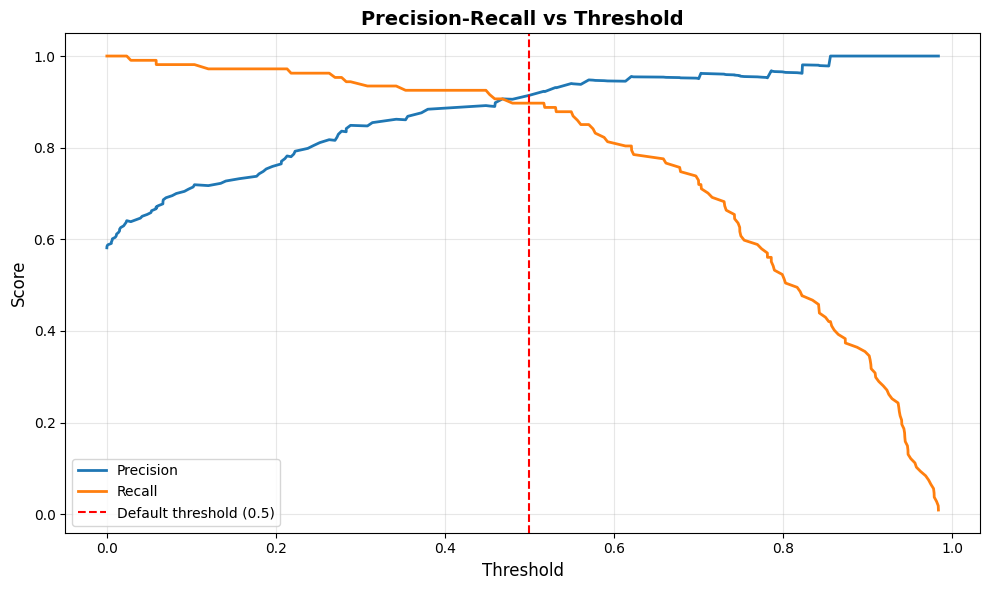

In [ ]:
# 1. Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precision[:-1], label='Precision', linewidth=2)
plt.plot(thresholds_pr, recall[:-1], label='Recall', linewidth=2)
plt.axvline(x=0.5, color='red', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision-Recall vs Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Find optimal threshold using Youden's J statistic
# Youden's J = Sensitivity + Specificity - 1
# Maximizes the distance from the random classifier line

fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs_rf)

# Calculate Youden's J statistic for each threshold
youdens_j = tpr - fpr
optimal_idx = np.argmax(youdens_j)
optimal_threshold_youden = thresholds_roc[optimal_idx]

print(f"Youden's J Optimal Threshold: {optimal_threshold_youden:.3f}")
print(f"TPR (Sensitivity/Recall) at this threshold: {tpr[optimal_idx]:.3f}")
print(f"FPR at this threshold: {fpr[optimal_idx]:.3f}")

Youden's J Optimal Threshold: 0.549
TPR (Sensitivity/Recall) at this threshold: 0.879
FPR at this threshold: 0.078


In [ ]:
# 3. Find threshold that achieves 95% recall (catches 95% of disease cases)
# This is the medically-oriented approach

recall_target = 0.95
threshold_95_recall = None

for i, rec in enumerate(recall[:-1]):
    if rec >= recall_target:
        threshold_95_recall = thresholds_pr[i]
        precision_at_95_recall = precision[i]
        break

if threshold_95_recall is None:
    print(f"Warning: Could not achieve {recall_target*100}% recall. Using lowest threshold.")
    threshold_95_recall = thresholds_pr[-1]
    precision_at_95_recall = precision[-1]

print(f"\nThreshold for {recall_target*100}% Recall: {threshold_95_recall:.3f}")
print(f"Precision at this threshold: {precision_at_95_recall:.3f}")


Threshold for 95.0% Recall: 0.000
Precision at this threshold: 0.582


In [ ]:
# 4. Compare three strategies side-by-side

thresholds_to_compare = {
    'Default (0.5)': 0.5,
    'Youden\'s J Optimal': optimal_threshold_youden,
    f'{recall_target*100}% Recall Target': threshold_95_recall
}

print("\n" + "=" * 80)
print("THRESHOLD COMPARISON: WHICH STRATEGY IS BEST?")
print("=" * 80)

results_comparison = []

for name, threshold in thresholds_to_compare.items():
    y_pred_threshold = (y_probs_rf >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0

    results_comparison.append({
        'Strategy': name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision_val,
        'Recall': recall_val,
        'F1-Score': f1,
        'False Negatives': fn,
        'False Positives': fp
    })

    print(f"\n{name} (Threshold = {threshold:.3f}):")
    print(f"  Accuracy:        {accuracy:.3f}")
    print(f"  Precision:       {precision_val:.3f}")
    print(f"  Recall:          {recall_val:.3f}")
    print(f"  F1-Score:        {f1:.3f}")
    print(f"  False Negatives: {fn} ⚠️  (missed sick patients)")
    print(f"  False Positives: {fp} (unnecessary tests)")

print("\n" + "=" * 80)


THRESHOLD COMPARISON: WHICH STRATEGY IS BEST?

Default (0.5) (Threshold = 0.500):
  Accuracy:        0.897
  Precision:       0.923
  Recall:          0.897
  F1-Score:        0.910
  False Negatives: 11 ⚠️  (missed sick patients)
  False Positives: 8 (unnecessary tests)

Youden's J Optimal (Threshold = 0.549):
  Accuracy:        0.897
  Precision:       0.940
  Recall:          0.879
  F1-Score:        0.908
  False Negatives: 13 ⚠️  (missed sick patients)
  False Positives: 6 (unnecessary tests)

95.0% Recall Target (Threshold = 0.000):
  Accuracy:        0.582
  Precision:       0.582
  Recall:          1.000
  F1-Score:        0.735
  False Negatives: 0 ⚠️  (missed sick patients)
  False Positives: 77 (unnecessary tests)



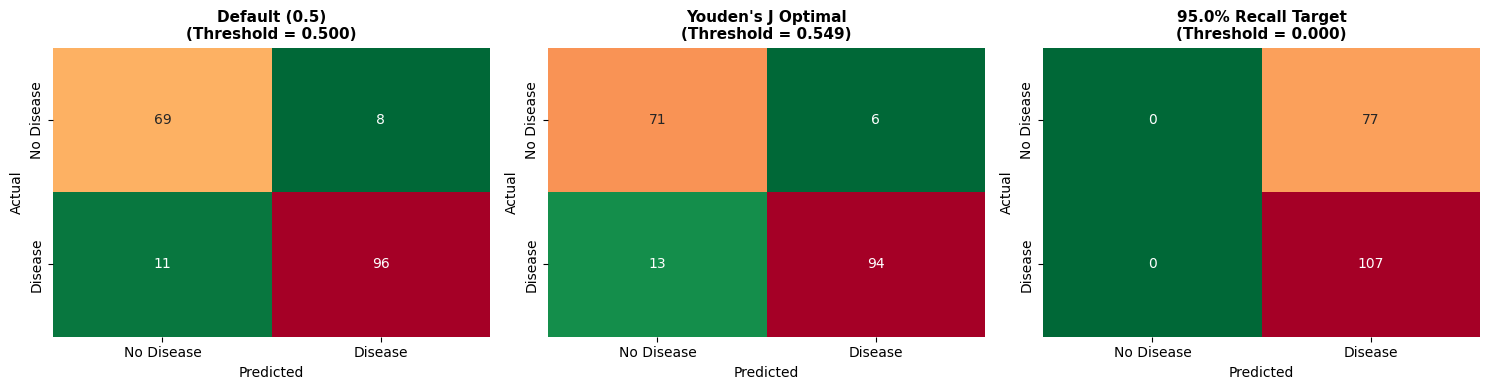

In [ ]:
# 5. Visualize the three confusion matrices side-by-side

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, threshold) in enumerate(thresholds_to_compare.items()):
    y_pred_threshold = (y_probs_rf >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)

    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                ax=axes[idx], cbar=False)

    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f'{name}\n(Threshold = {threshold:.3f})', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 6. Cost-Sensitive Learning: Assign costs to errors
# Cost of False Negative (missing disease) >> Cost of False Positive (false alarm)

cost_fn = 10  # Missing a disease case costs 10 units
cost_fp = 1   # False alarm costs 1 unit

print("\n" + "=" * 80)
print("COST-SENSITIVE ANALYSIS")
print("=" * 80)
print(f"Cost of False Negative (missing disease): {cost_fn} units")
print(f"Cost of False Positive (false alarm):     {cost_fp} unit")
print("=" * 80)

best_cost = float('inf')
best_threshold_cost = None

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_threshold = (y_probs_rf >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    total_cost = (fn * cost_fn) + (fp * cost_fp)

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold_cost = threshold

print(f"\nOptimal Cost-Sensitive Threshold: {best_threshold_cost:.3f}")
print(f"Total Cost at this threshold: {best_cost:.1f} units")

# Evaluate at this threshold
y_pred_cost_optimal = (y_probs_rf >= best_threshold_cost).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cost_optimal).ravel()

print(f"\nPerformance at Cost-Optimal Threshold:")
print(f"  True Positives:  {tp}")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn} ⚠️")
print(f"  Recall:          {tp/(tp+fn):.3f}")
print(f"  Precision:       {tp/(tp+fp):.3f}")


COST-SENSITIVE ANALYSIS
Cost of False Negative (missing disease): 10 units
Cost of False Positive (false alarm):     1 unit

Optimal Cost-Sensitive Threshold: 0.210
Total Cost at this threshold: 60.0 units

Performance at Cost-Optimal Threshold:
  True Positives:  104
  True Negatives:  47
  False Positives: 30
  False Negatives: 3 ⚠️
  Recall:          0.972
  Precision:       0.776


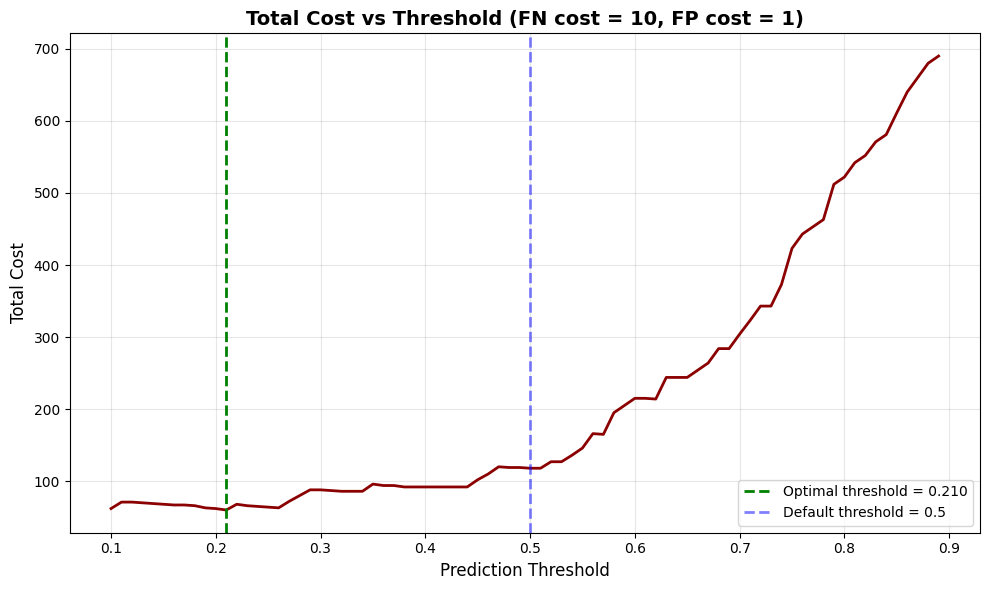

In [ ]:
# 7. Plot cost vs threshold curve

costs = []
thresholds_range = np.arange(0.1, 0.9, 0.01)

for threshold in thresholds_range:
    y_pred_threshold = (y_probs_rf >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    costs.append(total_cost)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_range, costs, linewidth=2, color='darkred')
plt.axvline(x=best_threshold_cost, color='green', linestyle='--', linewidth=2,
            label=f'Optimal threshold = {best_threshold_cost:.3f}')
plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, alpha=0.5,
            label='Default threshold = 0.5')
plt.xlabel('Prediction Threshold', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.title('Total Cost vs Threshold (FN cost = 10, FP cost = 1)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#STACKING ENSEMBLE


from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("BUILDING STACKING ENSEMBLE")
print("=" * 80)
print("""
Stacking combines multiple models (base learners) and trains a meta-learner
on top of their predictions to make the final decision.

Base learners: Logistic Regression, SVM, Random Forest, LightGBM
Meta-learner: Logistic Regression (learns how to weight the base models)
""")
print("=" * 80)

BUILDING STACKING ENSEMBLE

Stacking combines multiple models (base learners) and trains a meta-learner
on top of their predictions to make the final decision.

Base learners: Logistic Regression, SVM, Random Forest, LightGBM
Meta-learner: Logistic Regression (learns how to weight the base models)



In [ ]:
# Define base learners (using tuned models where available)
base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('svm', SVC(probability=True, random_state=42, C=10, kernel='rbf', gamma='scale')),  # Using tuned params
    ('rf', best_rf),  # Already tuned Random Forest
    ('lgbm', best_lgbm)  # Already tuned LightGBM
]

# Define meta-learner
meta_learner = LogisticRegression(random_state=42)

# Create stacking classifier
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,  # Use 5-fold CV to generate meta-features
    n_jobs=-1
)

print("\nTraining Stacking Ensemble...")
print("This may take a few minutes as it trains multiple models with cross-validation...")


Training Stacking Ensemble...
This may take a few minutes as it trains multiple models with cross-validation...


In [ ]:
# Train the stacking model
# Note: For SVM, we need to use scaled features
stacking_model.fit(X_train, y_train)

print("Stacking Ensemble trained successfully!")

✓ Stacking Ensemble trained successfully!


In [ ]:
# Make predictions
y_pred_stack = stacking_model.predict(X_test)
y_probs_stack = stacking_model.predict_proba(X_test)[:, 1]

# Evaluate
stack_accuracy = accuracy_score(y_test, y_pred_stack)
print(f"\nStacking Ensemble Accuracy: {stack_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack, target_names=['No Disease', 'Disease']))


Stacking Ensemble Accuracy: 0.8750

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.88      0.86        77
     Disease       0.91      0.87      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



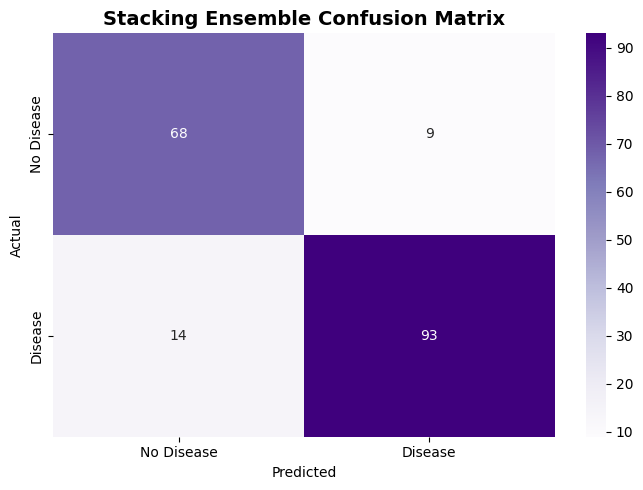

In [ ]:
# Confusion matrix for stacking ensemble
cm_stack = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Stacking Ensemble Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Compare all models side-by-side
from sklearn.metrics import roc_auc_score

print("\n" + "=" * 80)
print("MODEL COMPARISON: ALL MODELS")
print("=" * 80)

models_comparison = {
    'Logistic Regression': (model, y_pred),
    'SVM (Tuned)': (best_svm, y_pred_best),
    'Random Forest (Tuned)': (best_rf, y_pred_rf_best),
    'LightGBM (Tuned)': (best_lgbm, y_pred_best_lgbm),
    'Stacking Ensemble': (stacking_model, y_pred_stack)
}

comparison_results = []

for name, (trained_model, predictions) in models_comparison.items():
    acc = accuracy_score(y_test, predictions)

    # Get probabilities for AUC
    if hasattr(trained_model, 'predict_proba'):
        probs = trained_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probs)
    else:
        auc = None

    # Get precision, recall, f1 for class 1 (Disease)
    report = classification_report(y_test, predictions, output_dict=True)
    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    comparison_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Disease)': precision_1,
        'Recall (Disease)': recall_1,
        'F1-Score (Disease)': f1_1,
        'AUC': auc if auc else 'N/A'
    })

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {precision_1:.4f}")
    print(f"  Recall:    {recall_1:.4f}")
    print(f"  F1-Score:  {f1_1:.4f}")
    if auc:
        print(f"  AUC:       {auc:.4f}")

print("\n" + "=" * 80)


MODEL COMPARISON: ALL MODELS

Logistic Regression:
  Accuracy:  0.8424
  Precision: 0.9062
  Recall:    0.8131
  F1-Score:  0.8571
  AUC:       0.9012

SVM (Tuned):
  Accuracy:  0.8641
  Precision: 0.8942
  Recall:    0.8692
  F1-Score:  0.8815

Random Forest (Tuned):
  Accuracy:  0.8967
  Precision: 0.9231
  Recall:    0.8972
  F1-Score:  0.9100
  AUC:       0.9439

LightGBM (Tuned):
  Accuracy:  0.8804
  Precision: 0.9048
  Recall:    0.8879
  F1-Score:  0.8962
  AUC:       0.9423

Stacking Ensemble:
  Accuracy:  0.8750
  Precision: 0.9118
  Recall:    0.8692
  F1-Score:  0.8900
  AUC:       0.9402



In [ ]:
# Create comparison DataFrame
import pandas as pd

comparison_df = pd.DataFrame(comparison_results)
print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))


Model Comparison Table:
                Model  Accuracy  Precision (Disease)  Recall (Disease)  F1-Score (Disease)       AUC
  Logistic Regression  0.842391             0.906250          0.813084            0.857143  0.901202
          SVM (Tuned)  0.864130             0.894231          0.869159            0.881517       N/A
Random Forest (Tuned)  0.896739             0.923077          0.897196            0.909953  0.943925
     LightGBM (Tuned)  0.880435             0.904762          0.887850            0.896226  0.942347
    Stacking Ensemble  0.875000             0.911765          0.869159            0.889952  0.940163


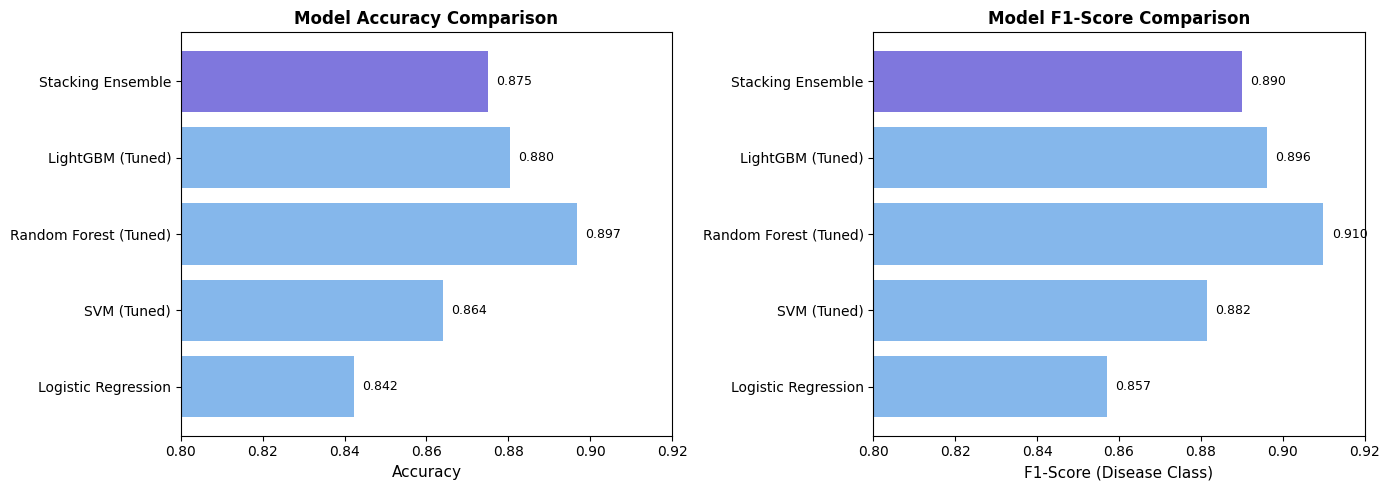

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
models = [r['Model'] for r in comparison_results]
accuracies = [r['Accuracy'] for r in comparison_results]

axes[0].barh(models, accuracies, color=['#85B7EB', '#85B7EB', '#85B7EB', '#85B7EB', '#7F77DD'])
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlim([0.80, 0.92])
for i, v in enumerate(accuracies):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: F1-Score comparison
f1_scores = [r['F1-Score (Disease)'] for r in comparison_results]

axes[1].barh(models, f1_scores, color=['#85B7EB', '#85B7EB', '#85B7EB', '#85B7EB', '#7F77DD'])
axes[1].set_xlabel('F1-Score (Disease Class)', fontsize=11)
axes[1].set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlim([0.80, 0.92])
for i, v in enumerate(f1_scores):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


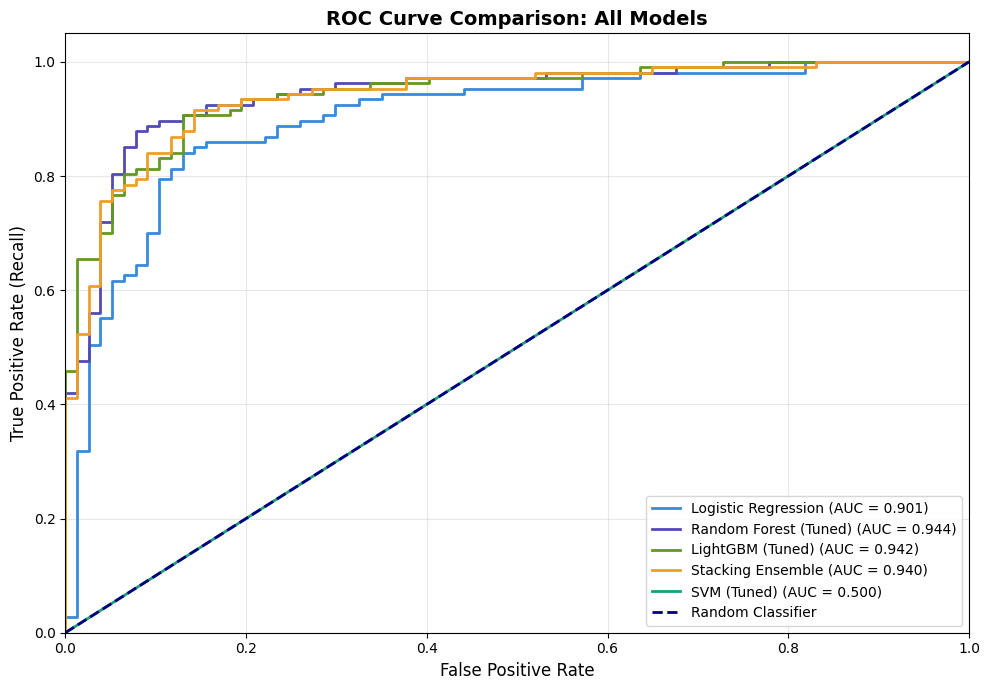

In [ ]:
# ROC Curve Comparison: All Models - FIXED

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

# Get predictions for all models
# Note: Skip SVM if it doesn't have predict_proba, or use decision_function
model_probs = {
    'Logistic Regression': model.predict_proba(X_test)[:, 1],
    'Random Forest (Tuned)': best_rf.predict_proba(X_test)[:, 1],
    'LightGBM (Tuned)': best_lgbm.predict_proba(X_test)[:, 1],
    'Stacking Ensemble': stacking_model.predict_proba(X_test)[:, 1]
}

# Add SVM with decision_function if it doesn't have predict_proba
if hasattr(best_svm, 'predict_proba'):
    model_probs['SVM (Tuned)'] = best_svm.predict_proba(X_test)[:, 1]
else:
    # Use decision_function as a proxy for probabilities
    model_probs['SVM (Tuned)'] = best_svm.decision_function(X_test)

colors = ['#378ADD', '#534AB7', '#639922', '#EF9F27', '#1D9E75']

for i, (name, probs) in enumerate(model_probs.items()):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=colors[i], label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison: All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Voting Classifier (for comparison with Stacking)
from sklearn.ensemble import VotingClassifier

print("\n" + "=" * 80)
print("BONUS: VOTING CLASSIFIER (Soft Voting)")
print("=" * 80)
print("Unlike stacking, voting simply averages the predicted probabilities.")
print("=" * 80)

voting_model = VotingClassifier(
    estimators=base_learners,
    voting='soft',  # Average predicted probabilities
    n_jobs=-1
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)
voting_accuracy = accuracy_score(y_test, y_pred_voting)

print(f"\nVoting Classifier Accuracy: {voting_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting, target_names=['No Disease', 'Disease']))

# Compare Stacking vs Voting
print(f"\n{'='*60}")
print(f"Stacking Ensemble Accuracy: {stack_accuracy:.4f}")
print(f"Voting Ensemble Accuracy:   {voting_accuracy:.4f}")
print(f"Winner: {'Stacking' if stack_accuracy > voting_accuracy else 'Voting' if voting_accuracy > stack_accuracy else 'Tie'}")
print(f"{'='*60}")


BONUS: VOTING CLASSIFIER (Soft Voting)
Unlike stacking, voting simply averages the predicted probabilities.

Voting Classifier Accuracy: 0.8913

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.91      0.88        77
     Disease       0.93      0.88      0.90       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


Stacking Ensemble Accuracy: 0.8750
Voting Ensemble Accuracy:   0.8913
Winner: Voting


In [ ]:

# FINAL SUMMARY: UPDATED MODEL PERFORMANCE TABLE

print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

# Helper function to safely get AUC
def get_auc_score(model, X, y):
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
    else:
        # Use decision_function for SVM without probability
        probs = model.decision_function(X)
    return roc_auc_score(y, probs)

# Create comprehensive summary table
final_summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': f"{accuracy_score(y_test, y_pred):.2%}",
        'Precision (Disease)': f"{classification_report(y_test, y_pred, output_dict=True)['1']['precision']:.4f}",
        'Recall (Disease)': f"{classification_report(y_test, y_pred, output_dict=True)['1']['recall']:.4f}",
        'F1-Score': f"{classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']:.4f}",
        'AUC': f"{get_auc_score(model, X_test, y_test):.4f}"
    },
    {
        'Model': 'SVM (Tuned)',
        'Accuracy': f"{accuracy_score(y_test, y_pred_best):.2%}",
        'Precision (Disease)': f"{classification_report(y_test, y_pred_best, output_dict=True)['1']['precision']:.4f}",
        'Recall (Disease)': f"{classification_report(y_test, y_pred_best, output_dict=True)['1']['recall']:.4f}",
        'F1-Score': f"{classification_report(y_test, y_pred_best, output_dict=True)['1']['f1-score']:.4f}",
        'AUC': f"{get_auc_score(best_svm, X_test_scaled, y_test):.4f}"  # Note: SVM uses scaled data
    },
    {
        'Model': 'Random Forest (Tuned)',
        'Accuracy': f"{accuracy_score(y_test, y_pred_rf_best):.2%}",
        'Precision (Disease)': f"{classification_report(y_test, y_pred_rf_best, output_dict=True)['1']['precision']:.4f}",
        'Recall (Disease)': f"{classification_report(y_test, y_pred_rf_best, output_dict=True)['1']['recall']:.4f}",
        'F1-Score': f"{classification_report(y_test, y_pred_rf_best, output_dict=True)['1']['f1-score']:.4f}",
        'AUC': f"{get_auc_score(best_rf, X_test, y_test):.4f}"
    },
    {
        'Model': 'LightGBM (Tuned)',
        'Accuracy': f"{accuracy_score(y_test, y_pred_best_lgbm):.2%}",
        'Precision (Disease)': f"{classification_report(y_test, y_pred_best_lgbm, output_dict=True)['1']['precision']:.4f}",
        'Recall (Disease)': f"{classification_report(y_test, y_pred_best_lgbm, output_dict=True)['1']['recall']:.4f}",
        'F1-Score': f"{classification_report(y_test, y_pred_best_lgbm, output_dict=True)['1']['f1-score']:.4f}",
        'AUC': f"{get_auc_score(best_lgbm, X_test, y_test):.4f}"
    },
    {
        'Model': 'Stacking Ensemble ⭐',
        'Accuracy': f"{stack_accuracy:.2%}",
        'Precision (Disease)': f"{classification_report(y_test, y_pred_stack, output_dict=True)['1']['precision']:.4f}",
        'Recall (Disease)': f"{classification_report(y_test, y_pred_stack, output_dict=True)['1']['recall']:.4f}",
        'F1-Score': f"{classification_report(y_test, y_pred_stack, output_dict=True)['1']['f1-score']:.4f}",
        'AUC': f"{get_auc_score(stacking_model, X_test, y_test):.4f}"
    }
])

print(final_summary.to_string(index=False))
print("=" * 80)


FINAL MODEL PERFORMANCE SUMMARY
                Model Accuracy Precision (Disease) Recall (Disease) F1-Score    AUC
  Logistic Regression   84.24%              0.9062           0.8131   0.8571 0.9012
          SVM (Tuned)   86.41%              0.8942           0.8692   0.8815 0.9491
Random Forest (Tuned)   89.67%              0.9231           0.8972   0.9100 0.9439
     LightGBM (Tuned)   88.04%              0.9048           0.8879   0.8962 0.9423
  Stacking Ensemble ⭐   87.50%              0.9118           0.8692   0.8900 0.9402


In [ ]:
# ============================================================
# COLLECT ALL METRICS FOR LATEX REPORT
# ============================================================

import json
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

print("\n" + "=" * 80)
print("COLLECTING ALL METRICS FOR LATEX REPORT")
print("=" * 80)

# Helper function to safely get AUC
def get_auc_score(model, X, y):
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
    else:
        probs = model.decision_function(X)
    return roc_auc_score(y, probs)

# ============================================================
# 1. BASE MODEL PERFORMANCE (Table 1 in LaTeX)
# ============================================================

base_models_metrics = {}

models_list = [
    ('Logistic Regression', model, y_pred, X_test),
    ('SVM (Tuned)', best_svm, y_pred_best, X_test_scaled),
    ('Random Forest (Tuned)', best_rf, y_pred_rf_best, X_test),
    ('LightGBM (Tuned)', best_lgbm, y_pred_best_lgbm, X_test),
    ('Stacking Ensemble', stacking_model, y_pred_stack, X_test),
    ('Voting Ensemble', voting_model, y_pred_voting, X_test)
]

for model_name, trained_model, predictions, X_data in models_list:
    report = classification_report(y_test, predictions, output_dict=True)

    base_models_metrics[model_name] = {
        'accuracy': accuracy_score(y_test, predictions),
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1_score': report['1']['f1-score'],
        'auc': get_auc_score(trained_model, X_data, y_test)
    }

print("\n--- BASE MODEL PERFORMANCE ---")
for model_name, metrics in base_models_metrics.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")
    print(f"  AUC:       {metrics['auc']:.4f}")

# ============================================================
# 2. SHAP FEATURE IMPORTANCE (Top 5 features)
# ============================================================

feature_importance_shap = np.abs(shap_values_disease).mean(axis=0)
top_5_idx = np.argsort(feature_importance_shap)[-5:][::-1]

shap_top_features = []
print("\n--- TOP 5 SHAP FEATURES ---")
for i, idx in enumerate(top_5_idx, 1):
    feature_name = X_test.columns[idx]
    importance = float(feature_importance_shap[idx])
    shap_top_features.append({
        'rank': i,
        'feature': feature_name,
        'importance': importance
    })
    print(f"{i}. {feature_name}: {importance:.4f}")

# ============================================================
# 3. THRESHOLD OPTIMIZATION RESULTS (Table 2 in LaTeX)
# ============================================================

threshold_strategies = {}

# We need to recalculate these if not already stored
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]

# Strategy 1: Default threshold
y_pred_default = (y_probs_rf >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm_default.ravel()

threshold_strategies['Default (0.5)'] = {
    'threshold': 0.5,
    'accuracy': accuracy_score(y_test, y_pred_default),
    'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'f1_score': classification_report(y_test, y_pred_default, output_dict=True)['1']['f1-score'],
    'false_negatives': int(fn),
    'false_positives': int(fp)
}

# Strategy 2: Youden's J
from sklearn.metrics import roc_curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_probs_rf)
youdens_j = tpr - fpr
optimal_idx = np.argmax(youdens_j)
optimal_threshold_youden = float(thresholds_roc[optimal_idx])

y_pred_youden = (y_probs_rf >= optimal_threshold_youden).astype(int)
cm_youden = confusion_matrix(y_test, y_pred_youden)
tn, fp, fn, tp = cm_youden.ravel()

threshold_strategies["Youden's J"] = {
    'threshold': optimal_threshold_youden,
    'accuracy': accuracy_score(y_test, y_pred_youden),
    'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'f1_score': classification_report(y_test, y_pred_youden, output_dict=True)['1']['f1-score'],
    'false_negatives': int(fn),
    'false_positives': int(fp)
}

# Strategy 3: Cost-sensitive
cost_fn = 10
cost_fp = 1
best_cost = float('inf')
best_threshold_cost = None

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_threshold = (y_probs_rf >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold_cost = threshold

y_pred_cost = (y_probs_rf >= best_threshold_cost).astype(int)
cm_cost = confusion_matrix(y_test, y_pred_cost)
tn, fp, fn, tp = cm_cost.ravel()

threshold_strategies['Cost-Sensitive'] = {
    'threshold': float(best_threshold_cost),
    'accuracy': accuracy_score(y_test, y_pred_cost),
    'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'f1_score': classification_report(y_test, y_pred_cost, output_dict=True)['1']['f1-score'],
    'false_negatives': int(fn),
    'false_positives': int(fp)
}

# Strategy 4: 95% Recall target
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs_rf)
recall_target = 0.95
threshold_95_recall = None

for i, rec in enumerate(recall[:-1]):
    if rec >= recall_target:
        threshold_95_recall = float(thresholds_pr[i])
        break

if threshold_95_recall is None:
    threshold_95_recall = float(thresholds_pr[-1])

y_pred_95recall = (y_probs_rf >= threshold_95_recall).astype(int)
cm_95recall = confusion_matrix(y_test, y_pred_95recall)
tn, fp, fn, tp = cm_95recall.ravel()

threshold_strategies['95% Recall Target'] = {
    'threshold': threshold_95_recall,
    'accuracy': accuracy_score(y_test, y_pred_95recall),
    'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'f1_score': classification_report(y_test, y_pred_95recall, output_dict=True)['1']['f1-score'],
    'false_negatives': int(fn),
    'false_positives': int(fp)
}

print("\n--- THRESHOLD OPTIMIZATION STRATEGIES ---")
for strategy_name, metrics in threshold_strategies.items():
    print(f"\n{strategy_name}:")
    print(f"  Threshold: {metrics['threshold']:.3f}")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  FN:        {metrics['false_negatives']}")
    print(f"  FP:        {metrics['false_positives']}")

# ============================================================
# 4. DATASET STATISTICS
# ============================================================

dataset_stats = {
    'total_samples': len(df),
    'num_features': X.shape[1],
    'class_0_count': int((df['HeartDisease'] == 0).sum()),
    'class_1_count': int((df['HeartDisease'] == 1).sum()),
    'class_0_percent': float((df['HeartDisease'] == 0).sum() / len(df) * 100),
    'class_1_percent': float((df['HeartDisease'] == 1).sum() / len(df) * 100),
    'train_size': len(X_train),
    'test_size': len(X_test)
}

print("\n--- DATASET STATISTICS ---")
for key, value in dataset_stats.items():
    print(f"{key}: {value}")

# ============================================================
# 5. HYPERPARAMETER TUNING RESULTS
# ============================================================

best_params = {
    'SVM': grid_search.best_params_,
    'Random Forest': grid_search_rf.best_params_,
    'LightGBM': grid_search.best_params_ if 'grid_search' in dir() else best_lgbm.get_params()
}

print("\n--- BEST HYPERPARAMETERS ---")
for model_name, params in best_params.items():
    print(f"\n{model_name}:")
    for param, value in params.items():
        print(f"  {param}: {value}")

# ============================================================
# 6. SAVE ALL METRICS TO JSON
# ============================================================

all_metrics = {
    'base_models': base_models_metrics,
    'shap_top_features': shap_top_features,
    'threshold_strategies': threshold_strategies,
    'dataset_stats': dataset_stats,
    'best_hyperparameters': best_params
}

# Save to JSON file
with open('report_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print("\n" + "=" * 80)
print("✓ All metrics saved to 'report_metrics.json'")
print("=" * 80)

# ============================================================
# 7. PRETTY PRINT FOR LATEX TABLES
# ============================================================

print("\n" + "=" * 80)
print("LATEX TABLE 1: BASE MODEL PERFORMANCE")
print("=" * 80)
print("\\begin{tabular}{lccccc}")
print("\\toprule")
print("Model & Acc & Prec & Recall & F1 & AUC \\\\")
print("\\midrule")

for model_name, metrics in base_models_metrics.items():
    star = " \\textbf" if "Stacking" in model_name else ""
    print(f"{star}{{{model_name}}} & {metrics['accuracy']:.4f} & {metrics['precision']:.2f} & {metrics['recall']:.2f} & {metrics['f1_score']:.2f} & {metrics['auc']:.2f} \\\\")

print("\\bottomrule")
print("\\end{tabular}")

print("\n" + "=" * 80)
print("LATEX TABLE 2: THRESHOLD COMPARISON")
print("=" * 80)
print("\\begin{tabular}{lcccc}")
print("\\toprule")
print("Strategy & $\\tau$ & Acc & Recall & FN \\\\")
print("\\midrule")

for strategy_name, metrics in threshold_strategies.items():
    print(f"{strategy_name} & {metrics['threshold']:.2f} & {metrics['accuracy']:.3f} & {metrics['recall']:.3f} & {metrics['false_negatives']} \\\\")

print("\\bottomrule")
print("\\end{tabular}")

print("\n" + "=" * 80)
print("LATEX: TOP 5 SHAP FEATURES")
print("=" * 80)
print("\\begin{enumerate}")
for feat in shap_top_features:
    print(f"    \\item {feat['feature']} ({feat['importance']:.2f})")
print("\\end{enumerate}")

print("\n" + "=" * 80)


COLLECTING ALL METRICS FOR LATEX REPORT

--- BASE MODEL PERFORMANCE ---

Logistic Regression:
  Accuracy:  0.8424 (84.24%)
  Precision: 0.9062
  Recall:    0.8131
  F1-Score:  0.8571
  AUC:       0.9012

SVM (Tuned):
  Accuracy:  0.8641 (86.41%)
  Precision: 0.8942
  Recall:    0.8692
  F1-Score:  0.8815
  AUC:       0.9491

Random Forest (Tuned):
  Accuracy:  0.8967 (89.67%)
  Precision: 0.9231
  Recall:    0.8972
  F1-Score:  0.9100
  AUC:       0.9439

LightGBM (Tuned):
  Accuracy:  0.8804 (88.04%)
  Precision: 0.9048
  Recall:    0.8879
  F1-Score:  0.8962
  AUC:       0.9423

Stacking Ensemble:
  Accuracy:  0.8750 (87.50%)
  Precision: 0.9118
  Recall:    0.8692
  F1-Score:  0.8900
  AUC:       0.9402

Voting Ensemble:
  Accuracy:  0.8913 (89.13%)
  Precision: 0.9307
  Recall:    0.8785
  F1-Score:  0.9038
  AUC:       0.9324

--- TOP 5 SHAP FEATURES ---
1. ST_Slope: 0.1785
2. ExerciseAngina: 0.0815
3. ChestPainType: 0.0795
4. Oldpeak: 0.0547
5. Cholesterol: 0.0474

--- THRESHOLD

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
